## VQEC (Variational Quantum Eigensolver with Constraints)

Based on arXiv:2311.08502.

With the perturbed primal-dual (PPD) method, each VQE iteration consists of four steps. The first two steps involve the generation of the perturbed primal and dual variables (i.e., VQE parameters and Lagrange multipliers):
$$
\begin{split}
\tilde{\boldsymbol{\theta}}^t &= \boldsymbol{\theta}^t - \nu_\theta \sum_{m=0}^M \lambda_m^t \nabla_{\boldsymbol{\theta}} F_m(\boldsymbol{\theta}^t), \\
\tilde{\lambda}_m^t &= \left[\lambda_m^t + \nu_\lambda F_m(\boldsymbol{\theta}^t)\right]_+, \qquad m = 1:M.
\end{split}
$$
It is then followed by the computation of the updated primal and dual variables:
$$
\begin{split}
\boldsymbol{\theta}^{t+1} &= \boldsymbol{\theta}^t - \mu_\theta^t \sum_{m=0}^M \tilde{\lambda}_m^t \nabla_{\boldsymbol{\theta}} F_m(\boldsymbol{\theta}^t), \\
\lambda_m^{t+1} &= \left[\lambda_m^t + \mu_\lambda^t F_m(\tilde{\boldsymbol{\theta}}^t)\right]_+, \qquad m = 1:M.
\end{split}.

In [28]:
from qiskit.circuit.library import TwoLocal, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import Estimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from qiskit_optimization import QuadraticProgram
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_optimization.algorithms import MinimumEigenOptimizer, GurobiOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

In [4]:
estimator = Estimator()
def get_expectation(observable, circuit, parameter_values):
    return estimator.run(circuit, observable, parameter_values).result().values[0]

In [19]:
# Objective function (4 qubits)
obj_op = SparsePauliOp.from_list([("IIII", 1), ("ZIII", 0.7), ("IZII", 0.2), ("IZZI", 0.3), ("IZIZ", 0.5)])

# Some cooked up constraints
constr_op_1 = SparsePauliOp.from_list([("IZIZ", 4), ("ZIZI", 2)])
constr_op_2 = SparsePauliOp.from_list([("ZZII", 2)])
constr_op_3 = SparsePauliOp.from_list([("ZIIZ", 3), ("IIZI", 3)])
constr_ops = [constr_op_1, constr_op_2, constr_op_3]

In [ ]:
# Convert operators to QuadraticProgram
qp = QuadraticProgram()
qp.from_ising(constr_op_3)
print(qp.prettyprint())

Problem name: 

Minimize
  -6*x0^2 + 12*x0*x3 - 6*x1^2 - 6*x3^2 + 6

Subject to
  No constraints

  Binary variables (4)
    x0 x1 x2 x3



In [50]:
qp = QuadraticProgram()
qp.from_ising(obj_op)
qp.quadratic_constraint(quadratic={("x0", "x0"): -8, ("x0", "x2"): 16, ("x1", "x1"): -4, ("x1", "x3"): 8, ("x2", "x2"): -8, ("x3", "x3"): -4}, sense="<=", rhs=-6)
qp.quadratic_constraint(quadratic={("x2", "x2"): -4, ("x2", "x3"): 8, ("x3", "x3"): -4}, sense="<=", rhs=-2)
qp.quadratic_constraint(quadratic={("x0", "x0"): -6, ("x0", "x3"): 12, ("x1", "x1"): -6, ("x3", "x3"): -6}, sense="<=", rhs=-6)
print(qp.prettyprint())

# Convert to QUBO
converter = QuadraticProgramToQubo()
print(converter.is_compatible(qp))

# # Solve the problem exactly
# exact_solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())
# exact_result = exact_solver.solve(qp)
# print(exact_result.prettyprint())


Problem name: 

Minimize
  -x0^2 + 2*x0*x2 - 0.6*x1^2 + 1.2*x1*x2 - 2*x2^2 - 1.4*x3^2 + 2.7

Subject to
  Quadratic constraints (3)
    -8*x0^2 + 16*x0*x2 - 4*x1^2 + 8*x1*x3 - 8*x2^2 - 4*x3^2 <= -6  'q0'
    -4*x2^2 + 8*x2*x3 - 4*x3^2 <= -2  'q1'
    -6*x0^2 + 12*x0*x3 - 6*x1^2 - 6*x3^2 <= -6  'q2'

  Binary variables (4)
    x0 x1 x2 x3

False


In [33]:
# Solve the problem with Gurobi
gurobi = GurobiOptimizer()
gurobi_result = gurobi.solve(qp)
print(gurobi_result.prettyprint())

Restricted license - for non-production use only - expires 2025-11-24
objective function value: -0.2999999999999998
variable values: x0=1.0, x1=1.0, x2=-0.0, x3=1.0
status: SUCCESS


In [60]:
#=================#
# Another problem instance starting from a quadratic program
obj_qp = QuadraticProgram()
obj_qp.binary_var('x1')
obj_qp.binary_var('x2')
obj_qp.binary_var('x3')
obj_qp.binary_var('x4')
obj_qp.minimize(quadratic={('x2', 'x3'): 2, ('x4', 'x4'): -1}, linear={'x1': 1}, constant=3)
obj_qp.linear_constraint(linear={'x1': 1, 'x4': 1}, sense='<=', rhs=1)
obj_qp.linear_constraint(linear={'x2': 1, 'x3': 1, 'x4': -2}, sense='<=', rhs=0)
obj_qp.quadratic_constraint(quadratic={('x2', 'x2'): 1}, linear={'x3': -2}, sense='<=', rhs=1)
print(obj_qp.prettyprint())

gurobi_result = gurobi.solve(obj_qp)
print(gurobi_result.prettyprint())

Problem name: 

Minimize
  2*x2*x3 - x4^2 + x1 + 3

Subject to
  Linear constraints (2)
    x1 + x4 <= 1  'c0'
    x2 + x3 - 2*x4 <= 0  'c1'

  Quadratic constraints (1)
    x2^2 - 2*x3 <= 1  'q0'

  Binary variables (4)
    x1 x2 x3 x4

objective function value: 2.0
variable values: x1=0.0, x2=0.0, x3=0.0, x4=1.0
status: SUCCESS


In [64]:
obj_op = SparsePauliOp(['IIIZ', 'IZZI', 'IIZI', 'IZII', 'ZIII', 'IIII'], coeffs=[-0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j, 3.5+0.j])
constr_op_1 = SparsePauliOp(['IIIZ', 'ZIII'], coeffs=[-0.5+0.j, -0.5+0.j])
constr_op_2 = SparsePauliOp(['IIZI', 'IZII', 'ZIII'], coeffs=[-0.5+0.j, -0.5+0.j, 1. +0.j])
constr_op_3 = SparsePauliOp(['IZII', 'IIZI', 'IIII'], coeffs=[1. +0.j, -0.5+0.j, -1.5+0.j])
constr_ops = [constr_op_1, constr_op_2, constr_op_3]

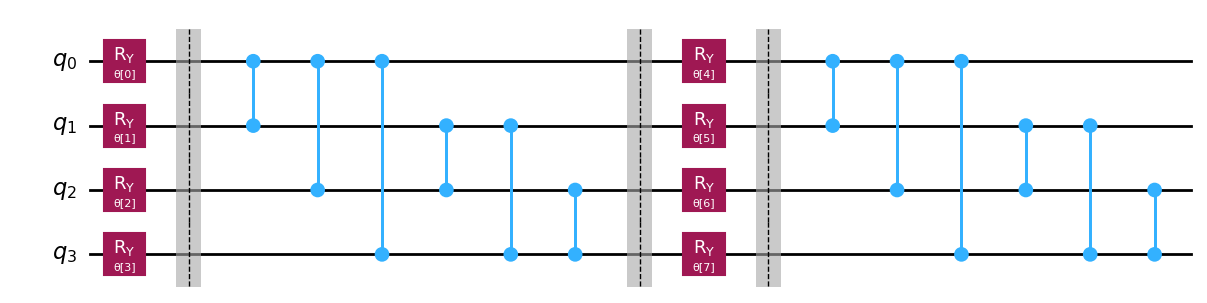

In [65]:
# Define the ansatz circuit
ansatz = TwoLocal(
    num_qubits=4,
    reps=2,
    entanglement='full',
    insert_barriers=True,
    rotation_blocks=['ry'],
    entanglement_blocks=['cz'],
    skip_final_rotation_layer=True
)

ansatz.decompose().draw(output='mpl')

In [35]:
# Set seed for reproducibility
np.random.seed(123)
param_vals = [np.random.random(ansatz.num_parameters)]
print(f"Parameter values: {param_vals}")

estimator = Estimator()

# Parameter shift rule
ps_grad = ParamShiftEstimatorGradient(estimator=estimator)
ps_grad_result = ps_grad.run(circuits=ansatz, observables=obj_op, parameter_values=param_vals).result()
print(f"Gradients from parameter shift rule: {ps_grad_result.gradients}")

# Linear combination of unitaries
lcu_grad = LinCombEstimatorGradient(estimator=estimator)
lcu_grad_result = lcu_grad.run(circuits=ansatz, observables=obj_op, parameter_values=param_vals).result()
print(f"Gradients from linear combination of unitaries: {lcu_grad_result.gradients}")

Parameter values: [array([0.69646919, 0.28613933, 0.22685145, 0.55131477, 0.71946897,
       0.42310646, 0.9807642 , 0.68482974])]
Gradients from parameter shift rule: [array([-0.04853706,  0.01617785, -0.55063651, -0.41731384, -0.19640348,
       -0.0770923 , -0.52207732, -0.58081656])]
Gradients from linear combination of unitaries: [array([-0.04853706,  0.01617785, -0.55063651, -0.41731384, -0.19640348,
       -0.0770923 , -0.52207732, -0.58081656])]


In [36]:
unperturbed_params = [np.random.random(ansatz.num_parameters)]
print(f"Parameter values: {unperturbed_params}")
[lcu_grad.run(circuits=[ansatz] * len(unperturbed_params), observables=constr_op, parameter_values=unperturbed_params).result().gradients for constr_op in constr_ops]

Parameter values: [array([0.4809319 , 0.39211752, 0.34317802, 0.72904971, 0.43857224,
       0.0596779 , 0.39804426, 0.73799541])]


[[array([-2.00651545, -0.14798074, -1.62991094, -1.00892748, -2.21889855,
         -0.48741268, -1.73617884, -1.72158951])],
 [array([ 4.35744556e-01,  3.45335186e-01, -7.84768380e-01, -1.61355649e+00,
          2.63515338e-16,  1.33573708e-16, -4.94143864e-01, -1.47179052e+00])],
 [array([-1.39819058e+00, -6.52375657e-01,  5.29306777e-01, -2.33472130e+00,
         -9.35224218e-01, -8.77908011e-01,  2.69153189e-16, -2.02809946e+00])]]

In [66]:
# VQEC (Variational Quantum Eigensolver with Constraints) workflow with perturbed primal-dual method
# np.random.seed(123)

param_perturb_step = 0.1
dual_perturb_step = 0.1
max_iter = 500
tol = 1e-5
# Initialize the parameters and dual variables
unperturbed_params = [np.random.uniform(0, 2 * np.pi, ansatz.num_parameters)]
unperturbed_dual_vars = np.array([0.1] * len(constr_ops))
print(f"Initial parameters: {unperturbed_params}")
print(f"Initial dual variables: {unperturbed_dual_vars}")

energies = [get_expectation(obj_op, ansatz, unperturbed_params)]
constraints_1 = [get_expectation(constr_op_1, ansatz, unperturbed_params)]
constraints_2 = [get_expectation(constr_op_2, ansatz, unperturbed_params)]
constraints_3 = [get_expectation(constr_op_3, ansatz, unperturbed_params)]
# Run the VQEC workflow
for i in tqdm(range(max_iter)):
    # Compute gradients for the objective and constraint operators
    obj_grad = (
        lcu_grad.run(
            circuits=ansatz, observables=obj_op, parameter_values=unperturbed_params
        )
        .result()
        .gradients
    )
    constr_grads = np.array(
        [
            lcu_grad.run(
                circuits=ansatz,
                observables=constr_op,
                parameter_values=unperturbed_params,
            )
            .result()
            .gradients
            for constr_op in constr_ops
        ]
    )
    # Compute the perturbed parameters
    param_perturbations = (
        np.array(
            [
                unperturbed_dual_var * constr_grad
                for unperturbed_dual_var, constr_grad in zip(
                    unperturbed_dual_vars, constr_grads
                )
            ]
        ).sum(axis=0)
        + obj_grad
    )
    # print(f"Param perturbations at iteration {i+1}: {param_perturbations}")
    perturbed_params = unperturbed_params - param_perturb_step * param_perturbations
    # print(f"Perturbed parameters at iteration {i+1}: {perturbed_params}")

    # Compute the perturbed dual variables
    dual_var_perturbations = np.array(
        [
            get_expectation(constr_op, ansatz, unperturbed_params)
            for constr_op in constr_ops
        ]
    )
    # print(f"Dual var perturbations at iteration {i+1}: {dual_var_perturbations}")
    perturbed_dual_vars = np.maximum(
        unperturbed_dual_vars + dual_perturb_step * dual_var_perturbations, 0
    )
    # print(f"Perturbed dual variables at iteration {i+1}: {perturbed_dual_vars}")

    # Set up the update step sizes
    param_update_step = 0.05 * 0.99**i
    dual_var_update_step = 0.05 * 0.99**i

    # Compute the updated parameters
    param_updates = (
        np.array(
            [
                perturbed_dual_var * constr_grad
                for perturbed_dual_var, constr_grad in zip(
                    perturbed_dual_vars, constr_grads
                )
            ]
        ).sum(axis=0)
        + obj_grad
    )
    # print(f"Param updates at iteration {i+1}: {param_updates}")
    updated_params = unperturbed_params - param_update_step * param_updates
    # print(f"Updated parameters at iteration {i+1}: {updated_params}")

    # Compute the updated dual variables
    dual_var_updates = np.array(
        [get_expectation(constr_op, ansatz, perturbed_params) for constr_op in constr_ops]
    )
    # print(f"Dual var updates at iteration {i+1}: {dual_var_updates}")
    updated_dual_vars = np.maximum(
        unperturbed_dual_vars + dual_var_update_step * dual_var_updates, 0
    )
    # print(f"Updated dual variables at iteration {i+1}: {updated_dual_vars}")

    # Compute the energy at the updated parameters
    energies.append(get_expectation(obj_op, ansatz, updated_params))
    constraints_1.append(get_expectation(constr_op_1, ansatz, updated_params))
    constraints_2.append(get_expectation(constr_op_2, ansatz, updated_params))
    constraints_3.append(get_expectation(constr_op_3, ansatz, updated_params))

    # Check for convergence
    if (
        np.linalg.norm(updated_params - unperturbed_params)
        / np.linalg.norm(unperturbed_params)
        < tol
    ):
        print(f"Converged after {i+1} iterations")
        break
    # if np.abs(energies[-1] - energies[-2]) / np.abs(energies[-2]) < tol:
    #     print(f"Converged after {i+1} iterations")
    #     break

    # Update the parameters and dual variables
    unperturbed_params = updated_params
    unperturbed_dual_vars = updated_dual_vars

Initial parameters: [array([2.62022783, 4.28073896, 5.50065757, 3.20707813, 4.20542253,
       3.68154794, 3.9263845 , 4.23919633])]
Initial dual variables: [0.1 0.1 0.1]


 78%|███████▊  | 388/500 [00:13<00:03, 29.46it/s]

Converged after 389 iterations


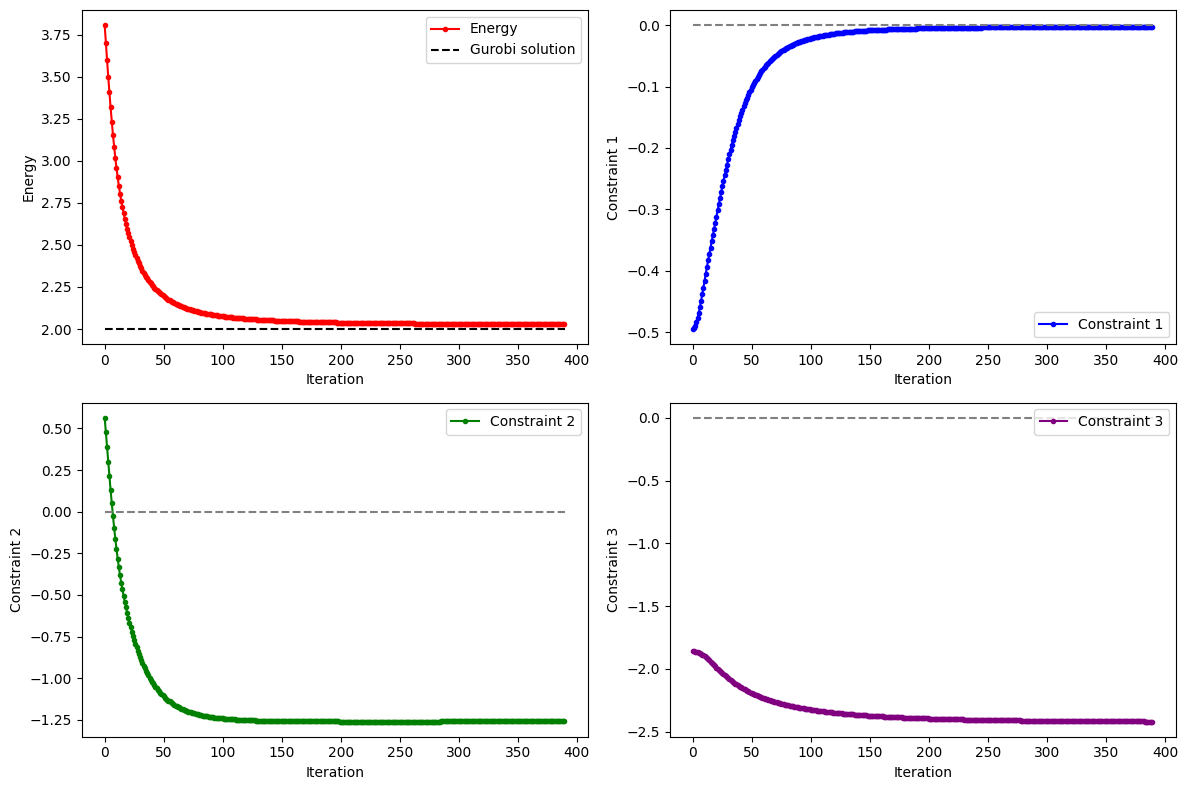

In [67]:
# Plot the energy and constraints
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(energies, label="Energy", color="red", marker=".")
axes[0, 0].hlines(gurobi_result.fval, 0, len(energies), color="black", linestyle="--", label="Gurobi solution")
axes[0, 0].set_ylabel("Energy")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].legend()
axes[0, 1].plot(constraints_1, label="Constraint 1", color="blue", marker=".")
axes[0, 1].hlines(0, 0, len(constraints_1), color="gray", linestyle="--")
axes[0, 1].set_ylabel("Constraint 1")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].legend()
axes[1, 0].plot(constraints_2, label="Constraint 2", color="green", marker=".")
axes[1, 0].hlines(0, 0, len(constraints_1), color="gray", linestyle="--")
axes[1, 0].set_ylabel("Constraint 2")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].legend()
axes[1, 1].plot(constraints_3, label="Constraint 3", color="purple", marker=".")
axes[1, 1].hlines(0, 0, len(constraints_1), color="gray", linestyle="--")
axes[1, 1].set_ylabel("Constraint 3")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].legend()
plt.tight_layout()
plt.show()


TODO:
- ~~Find the optimal solution by classical solver to assess the optimality of the variational solution.~~
- Hyperparameter tuning for the variational solution: $\nu_\theta$, $\nu_\lambda$, $\mu_\theta^t$, and $\mu_\lambda^t$.